In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Our sample data

data = {
    "size_sqft": [850, 920, 1100, 1450, 1600, 2100, 2300, 2600, 2800, 3100,
                  3300, 3600, 3900, 4100, 4300, 4600, 4900, 5100, 5400, 5700],

    "bedrooms": [2, 2, 3, 3, 3, 4, 4, 5, 4, 5,
                 6, 5, 6, 7, 6, 7, 8, 7, 8, 9],

    "age": [25, 30, 18, 12, 20, 10, 15, 8, 12, 6,
            5, 7, 4, 3, 6, 2, 3, 5, 2, 1],

    "distance_city": [20, 18, 15, 10, 12, 9, 11, 7, 13, 5,
                      6, 8, 4, 3, 7, 2, 3, 6, 2, 1],

    "price": [100000, 115000, 160000, 210000, 195000, 310000, 290000, 370000, 340000, 450000,
              480000, 460000, 600000, 620000, 590000, 680000, 720000, 700000, 770000, 820000]
}

df = pd.DataFrame(data)

In [3]:
df.head()

,size_sqft,bedrooms,age,distance_city,price
0,850,2,25,20,100000
1,920,2,30,18,115000
2,1100,3,18,15,160000
3,1450,3,12,10,210000
4,1600,3,20,12,195000


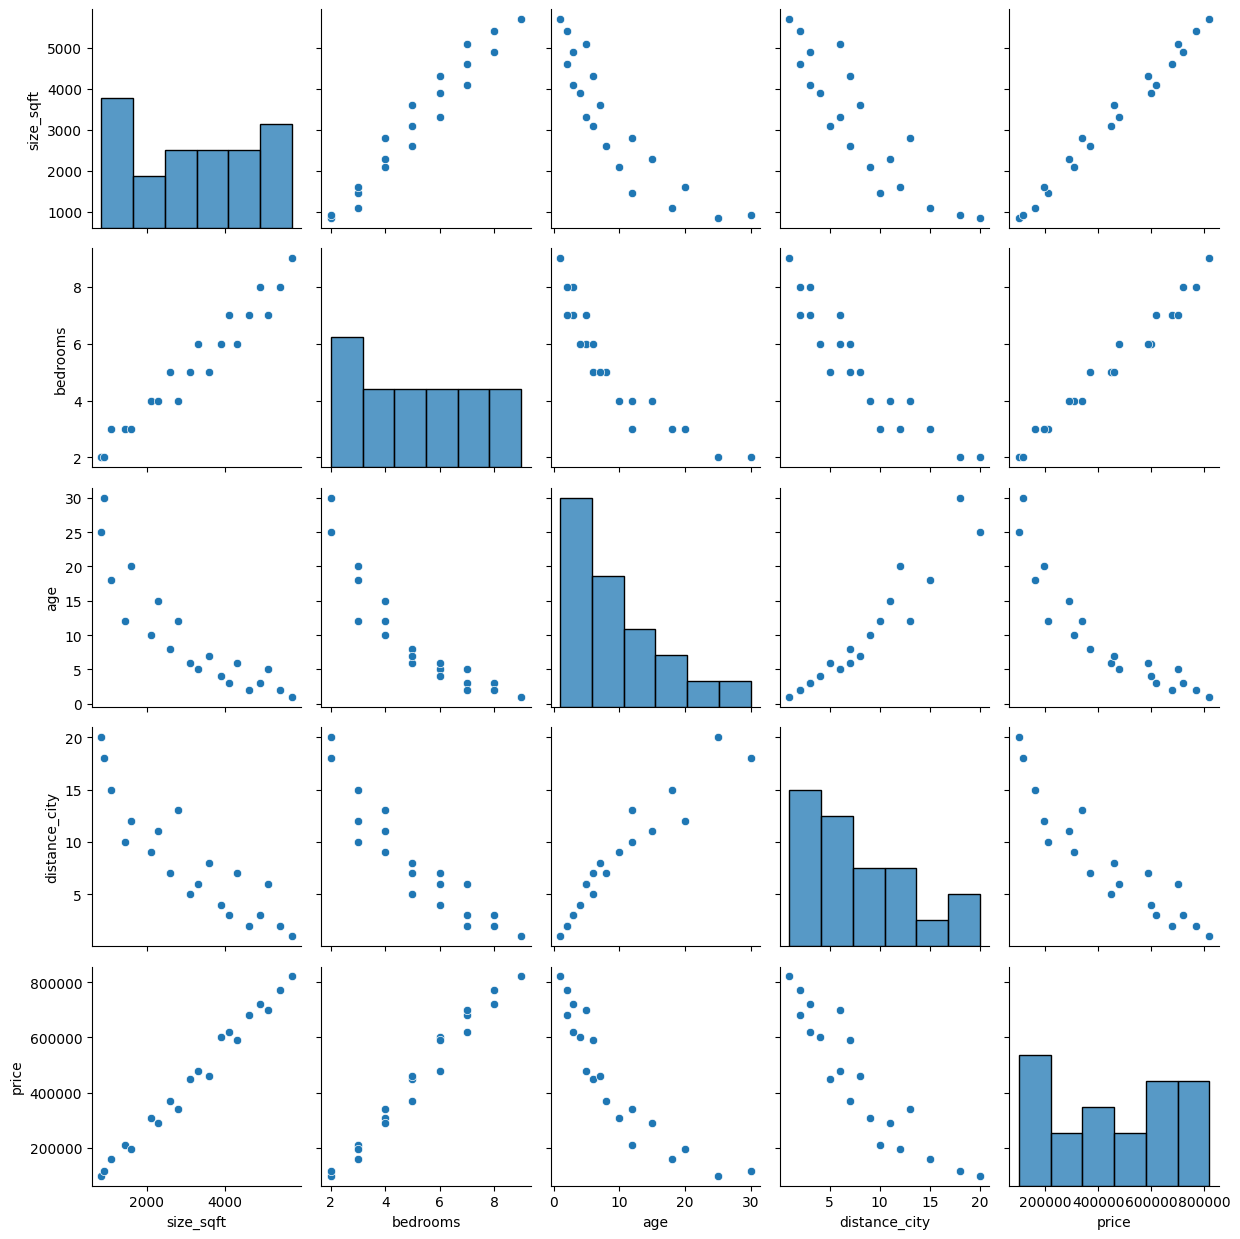

In [24]:
# Data distributions
sns.pairplot(data = df, diag_kind= 'hist')
plt.tight_layout()
plt.show()

In [34]:
# Defining some colors
colors = [
    "#2C7BB6",  # blue
    "#00A6D6",  # sky blue
    "#00C2C7",  # cyan
    "#2DD4BF",  # teal
    "#3B82F6",  # bright blue
    "#6366F1",  # indigo
    "#8B5CF6",  # purple
    "#0EA5E9",  # light blue
    "#06B6D4",  # turquoise
    "#1E3A8A"   # deep navy
]

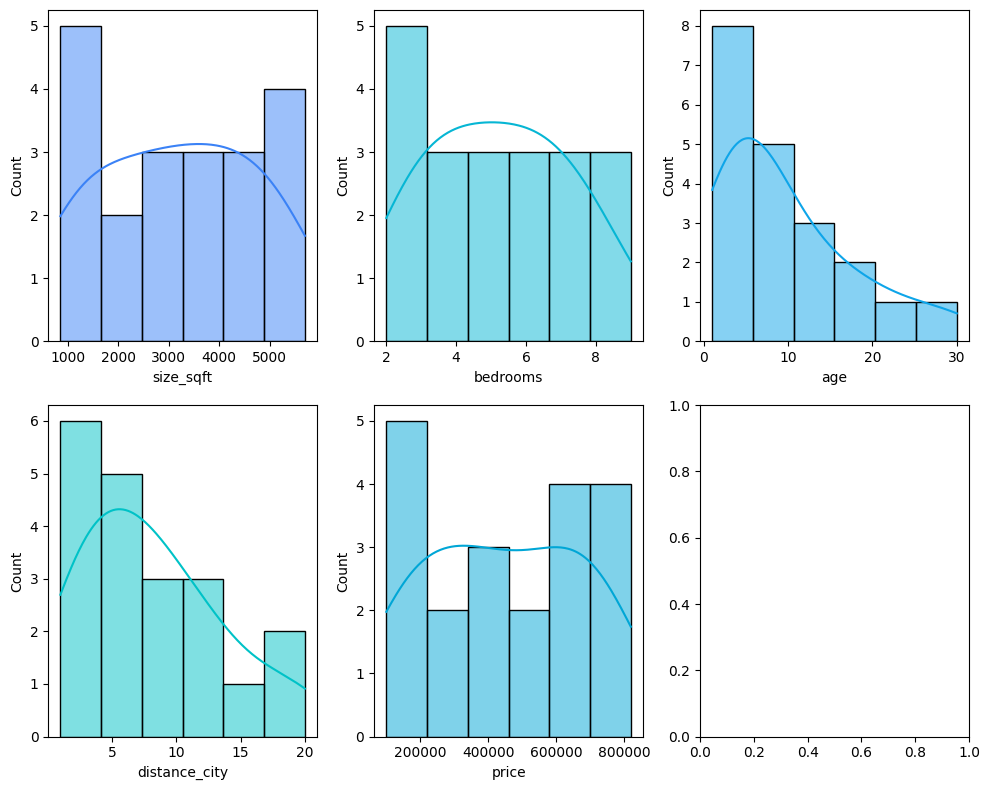

In [37]:
fig, axes = plt.subplots(2,3, figsize=(10,8))

for (axe, col) in zip(axes.flatten(), df.columns):
    sns.histplot(data= df, x= col, ax= axe, kde= True, color= np.random.choice(colors))

plt.tight_layout()
plt.show()

In [38]:
# Checking for skewness
df.skew()

size_sqft       -0.011324
bedrooms         0.100081
age              1.203804
distance_city    0.741704
price            0.004917
dtype: float64

In [ ]:
"""
The size_sqft, and bedrooms features are normally ditributed, and they 
present a good linear relationship with the target feature,
while the age and distance_city are little bit skewed, and also they present a curved
relationship with the target feature(price), so we are going to log transform them.
"""

In [39]:
# Log transform
df['age_log'] = np.log(df['age']+1) 
df['distance_city_log'] = np.log(df['distance_city']+1)
df.head()

,size_sqft,bedrooms,age,distance_city,price,age_log,distance_city_log
0,850,2,25,20,100000,3.258097,3.044522
1,920,2,30,18,115000,3.433987,2.944439
2,1100,3,18,15,160000,2.944439,2.772589
3,1450,3,12,10,210000,2.564949,2.397895
4,1600,3,20,12,195000,3.044522,2.564949


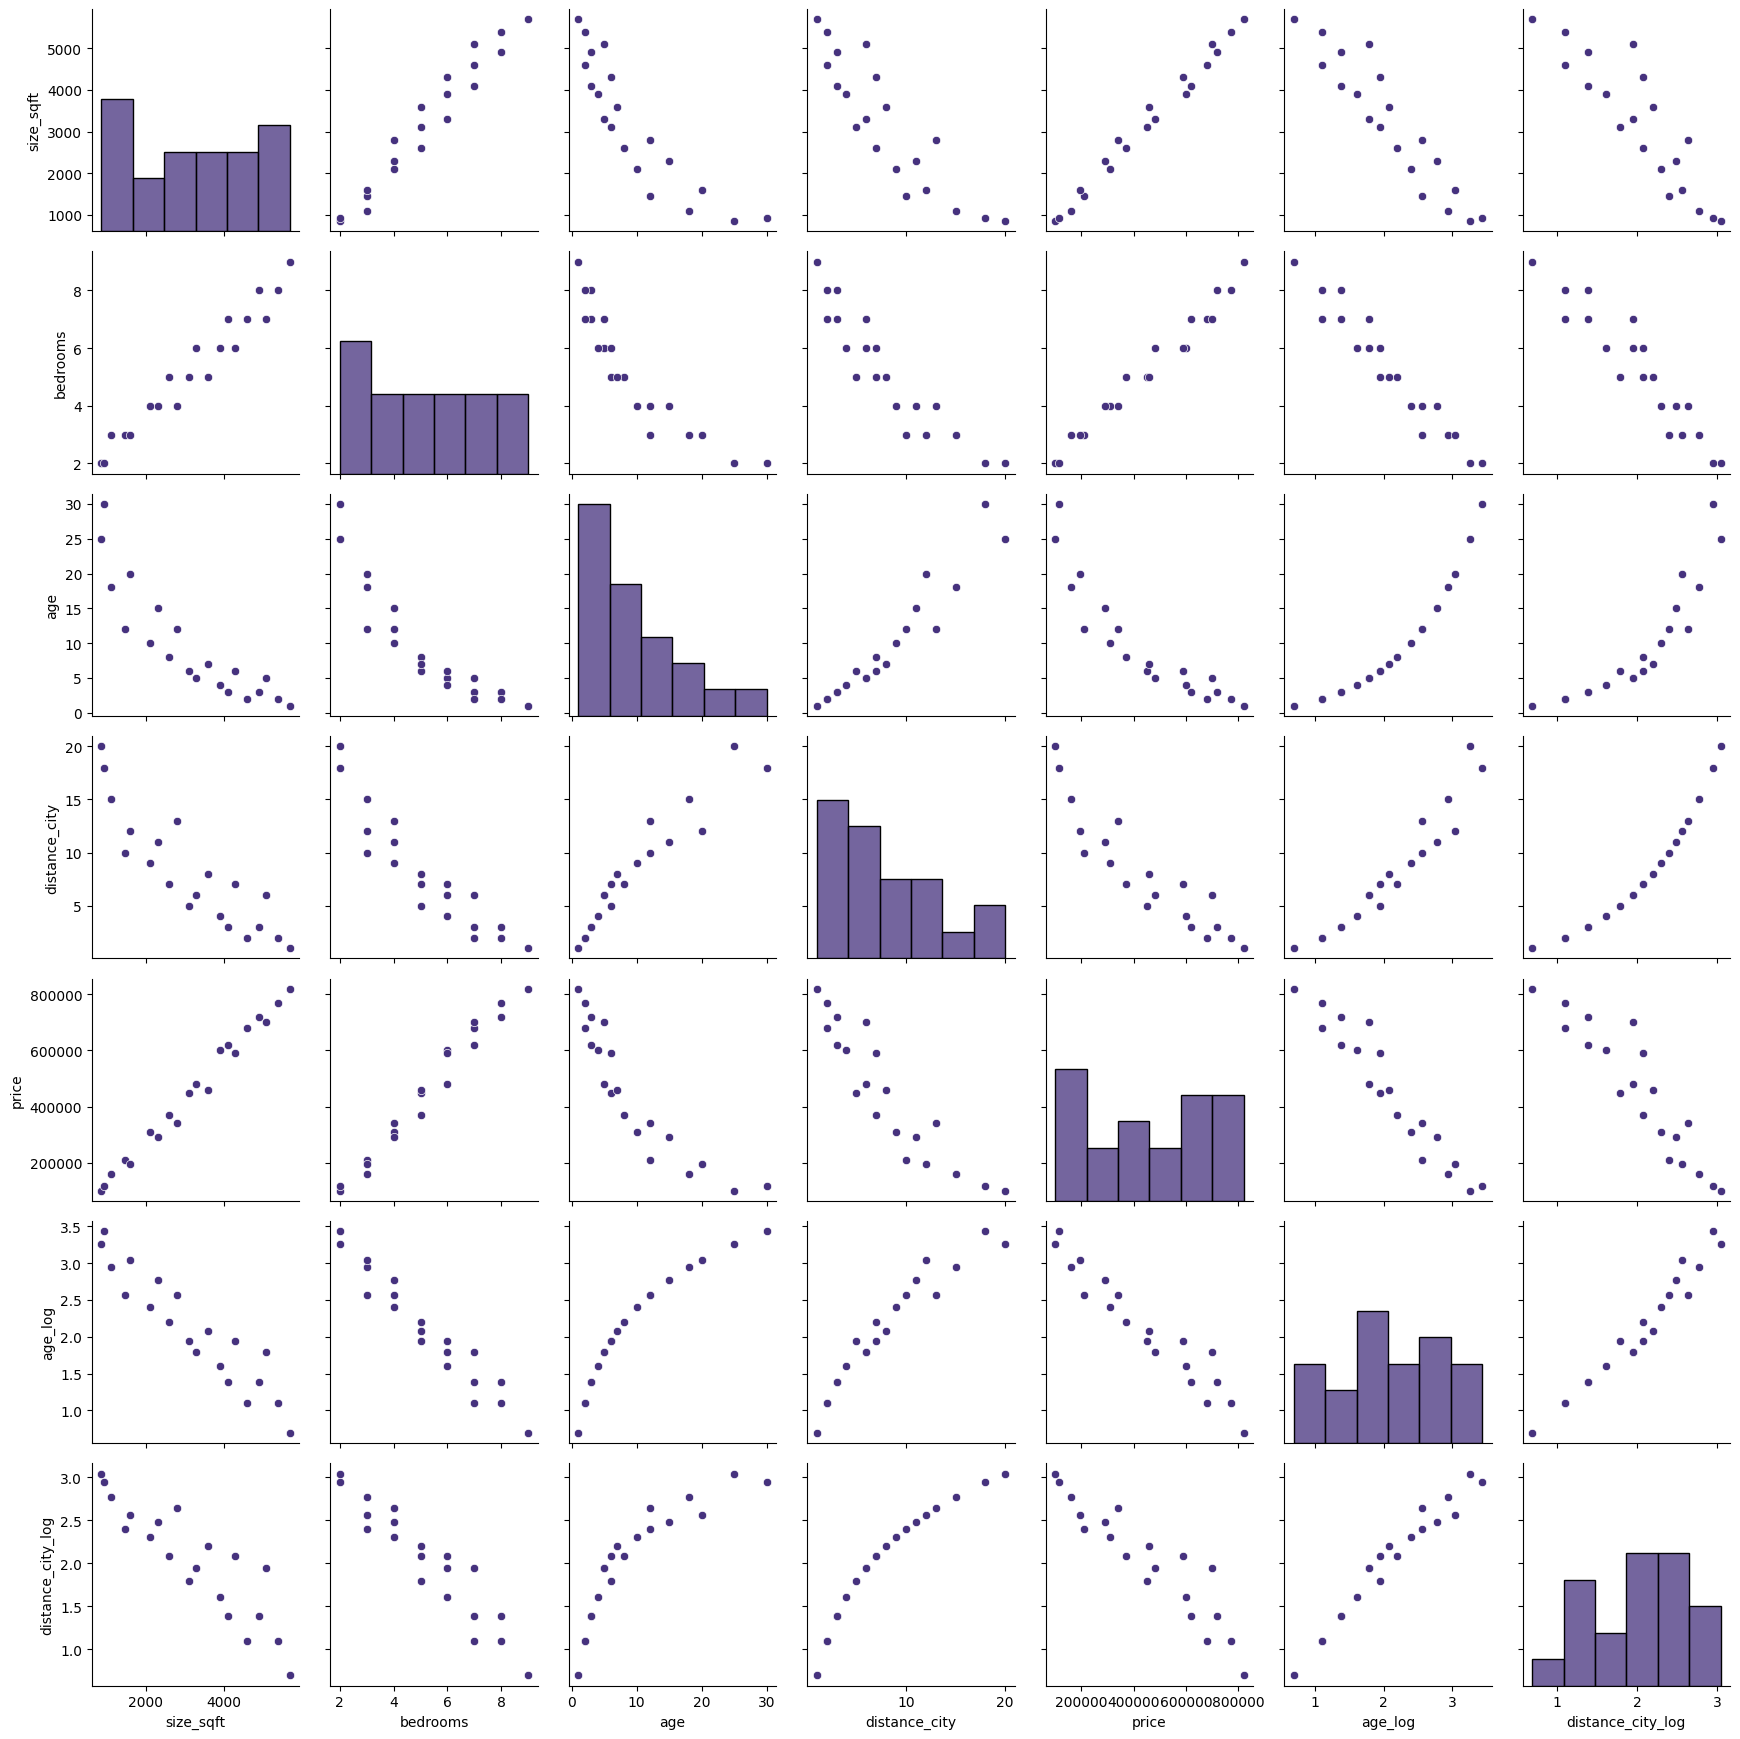

In [40]:
# Checking for distributions again distributions
sns.pairplot(data = df, diag_kind= 'hist')
plt.tight_layout()
plt.show()

In [ ]:
# The ditribution is way more better now

In [42]:
# Splitting data
x_train = df[['size_sqft', 'bedrooms', 'age_log', 'distance_city_log']]
x_train.head()

,size_sqft,bedrooms,age_log,distance_city_log
0,850,2,3.258097,3.044522
1,920,2,3.433987,2.944439
2,1100,3,2.944439,2.772589
3,1450,3,2.564949,2.397895
4,1600,3,3.044522,2.564949


In [43]:
y_train = df['price']
y_train.head()

0    100000
1    115000
2    160000
3    210000
4    195000
Name: price, dtype: int64

In [44]:
# Normalizing data
x_train_norm = (x_train - x_train.mean()) / x_train.std()
y_train_norm = (y_train - y_train.mean()) / y_train.std()

In [47]:
# Training the model
from algorithm import LinearRegression

reg = LinearRegression()

info = reg.fit(x_train_norm, y_train_norm)

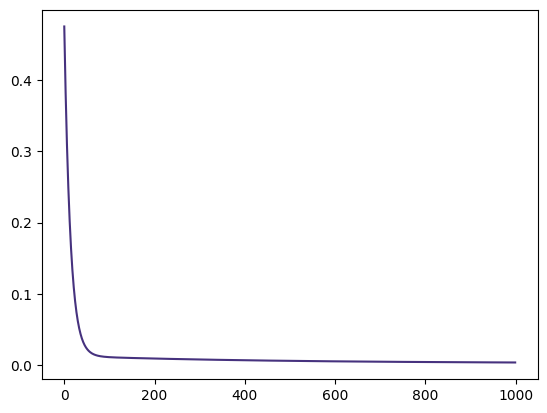

In [48]:
# Loss curve
plt.plot(info['cost_history'])
plt.show()

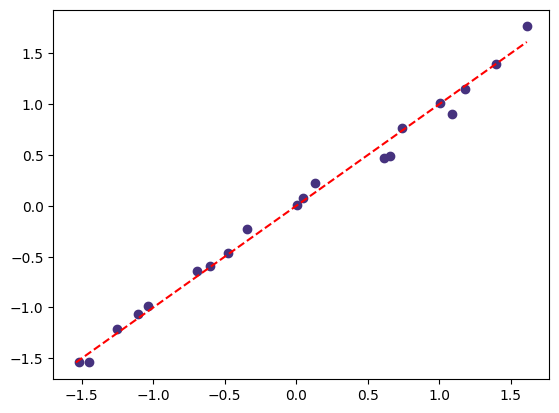

In [53]:
# Actual .Vs Predicted values

y_pred_norm = x_train_norm @ info['weight'] + info['bias']

y_line = np.linspace(np.min(y_pred_norm), np.max(y_pred_norm), 100)
limits = [
    np.min([np.min(y_pred_norm), np.max(y_pred_norm)]),
    np.max([np.min(y_train_norm), np.max(y_train_norm)])
]

plt.scatter(y_train_norm, y_pred_norm)
plt.plot(limits, limits, color = 'red', linestyle= '--')
plt.show()